In [1]:
import pandas as pd
df = pd.read_csv("C:/Users/Saini/Desktop/Bp-care/BP_care1.csv")
df.head()

,Patient_ID,Age,Gender,Region,Weight (kg),BP_Category,Diabetes,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,...,Stress_Level,Medication_Compliance,Family_History_Hypertension,Exercise_Recommendation,Diet_Recommendation,Remedies,Follow_Up_Advice,Support_Type,Support_Tips,heart_beat_level
0,P001,1,Male,Urban,1,Stage 2,Yes,Current,Heavy,Sedentary,...,High,No,Yes,"Brisk walk 5x/week, yoga 3x/week","Low-salt, DASH diet, avoid processed food","Garlic, hibiscus tea, flaxseed","Weekly BP check, monthly doctor visit","Dietician, Fitness Coach, Therapist","Join BP care group, use BP tracking app",Normal
1,P002,2,Female,Rural,2,Stage 1,No,Never,Moderate,Moderate,...,Medium,Yes,No,"Jogging 3x/week, swimming 2x/week","Balanced diet, reduce red meat","Green tea, turmeric water",BP check every 2 weeks,"Health Coach, Peer Support","Regular group walks, motivational calls",Normal
2,P003,3,Female,Semi-Urban,3,Stage 2,Yes,Former,NaN,Sedentary,...,High,No,Yes,"Walking daily, deep breathing","Low-sodium, high-fiber, avoid sugar","Ashwagandha, beetroot juice",BP check every 2 weeks,"Doctor, Yoga Instructor","Daily yoga videos, BP reminders",Normal
3,P004,4,Female,Urban,4,Stage 2,Yes,Former,NaN,Sedentary,...,High,No,Yes,"Walking daily, deep breathing",NaN,NaN,BP check every 2 weeks,"Health Coach, Peer Support",Maintain a healthy lifestyle,Normal
4,P005,5,Female,Urban,5,Stage 1,Yes,Former,NaN,Sedentary,...,High,No,Yes,"Walking daily, deep breathing",NaN,NaN,BP check every 2 weeks,"Health Coach, Peer Support",Maintain a healthy lifestyle,Normal


In [3]:
input_cols = ['Age', 'Gender', 'Region', 'Weight (kg)', 'BP_Category',
               'heart_beat_level', 'Diabetes', 'Smoking_Status',
              'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Score',
              'Stress_Level', 'Medication_Compliance', 'Family_History_Hypertension']

output_cols = ['Exercise_Recommendation', 'Diet_Recommendation', 'Remedies',
               'Follow_Up_Advice','heart_beat_level', 'Support_Type', 'Support_Tips']

X = df[input_cols]
y = df[output_cols]

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode X
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Encode y
y_encoded = y.copy()
label_encoders = {}
for col in y.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y[col])
    label_encoders[col] = le

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

base_model = RandomForestClassifier(n_estimators=100, random_state=42)
model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = [accuracy_score(y_test[col], y_pred[:, i]) for i, col in enumerate(y.columns)]

for col, acc in zip(y.columns, accuracy):
    print(f"{col} Accuracy: {acc:.2f}")

Exercise_Recommendation Accuracy: 0.83
Diet_Recommendation Accuracy: 0.94
Remedies Accuracy: 0.94
Follow_Up_Advice Accuracy: 0.89
heart_beat_level Accuracy: 1.00
Support_Type Accuracy: 0.94
Support_Tips Accuracy: 0.67


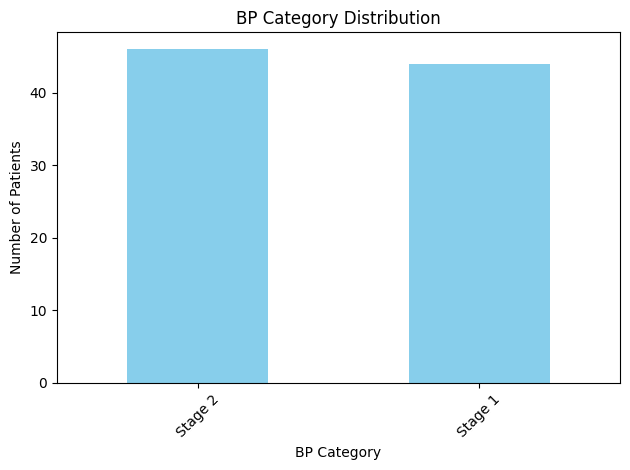

In [9]:
import matplotlib.pyplot as plt

df['BP_Category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("BP Category Distribution")
plt.xlabel("BP Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


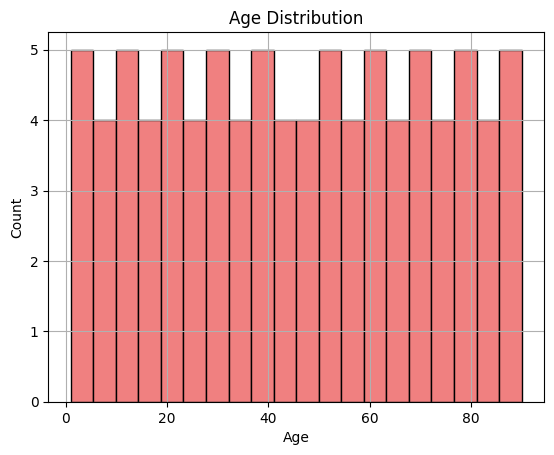

In [10]:
plt.hist(df['Age'], bins=20, color='lightcoral', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()


ValueError: Could not interpret value `heart_rate_level` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>